**🏨 Hotel Booking  Analysis**

**By: Kashish**

**Dataset: Kaggle — Hotel Booking Demand**

**Tools: Python, Pandas, Matplotlib**

# **Hotel Booking Analysis**

##  Introduction

In this project, we analyze a hotel booking dataset to understand 
booking patterns, cancellation trends, and customer behavior.

The dataset contains information about **two types of hotels:**
- 🏙️ **City Hotel**
- 🏖️ **Resort Hotel**

**Goals of this analysis:**
- Identify factors that affect cancellations
- Understand booking trends over time
- Analyze which countries have the most bookings
- Find peak booking seasons

## Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [3]:
df=pd.read_csv("hotel_bookings.csv")

## 2. Dataset Overview

In [4]:
print("-----Shape of Dataset----:", df.shape)
print("\n----Total Rows------:", df.shape[0])
print("\n----Total Columns----:", df.shape[1])




-----Shape of Dataset----: (119390, 32)

----Total Rows------: 119390

----Total Columns----: 32


In [5]:

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [7]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### stats of the dataset

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [10]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [11]:

df.isnull().sum()




hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

* `Children` 4 missing values

* `Country` 488 missing values

* `Agent` 16,340 missing values

* `Company` 112,593 missing values (likely due to many bookings not being linked to a company)

In [12]:
(df.isnull().sum( ) / df.shape[0]) * 100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

`Company(94% missing values)`=Most bookings are not associated with a company.

Approach:we drop this column.


`Agent(14% missing values)`=It can still provide valuable insights about booking channels.
 
Approach:we fill this column with 'unknown'to avoid losing potentially useful booking information.


`Country(0.51% missing values)`=This is a small portion of the overall data, so these rows can either be filled with the most common country.

Approach:Filled with the most common country (mode).

### checking the number of duplicates

In [13]:
print(df.duplicated().sum())

31994


## **Data Cleaning** ##

## ---Removing Duplicates--- ##

In [14]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


## ---Handling Missing Values--- ##

`country`

In [15]:
df["country"] = df["country"].fillna(df["country"].mode()[0])


`Agent`

In [16]:
#  fill NaN
df["agent"] = df["agent"].fillna(0)

#  - then convert
df["agent"] = df["agent"].astype(int)

`Company`

In [17]:
df.drop("company",axis=1,inplace=True)

`children`

In [18]:
df["children"] = df["children"].fillna(0).astype(int)

### Change date from Str To Datetime Formate ###

In [19]:
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

In [20]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

## Feature Engineering ##

`Adding New Calculated Fields`

In [21]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['revenue_per_stay'] = df['adr'] * df['total_nights']


## Handling Outliers 

`check for outliers`

In [22]:
print(df["adr"].min())
print(df["adr"].max())
print(df["stays_in_week_nights"].max())
print(df["stays_in_weekend_nights"].max())

-6.38
5400.0
50
19


`-6.38 adr`-negative values definietly an outlier.

`5400 adr`-according to boxplot mostoff values are under 5000 so its definietly an outlier.

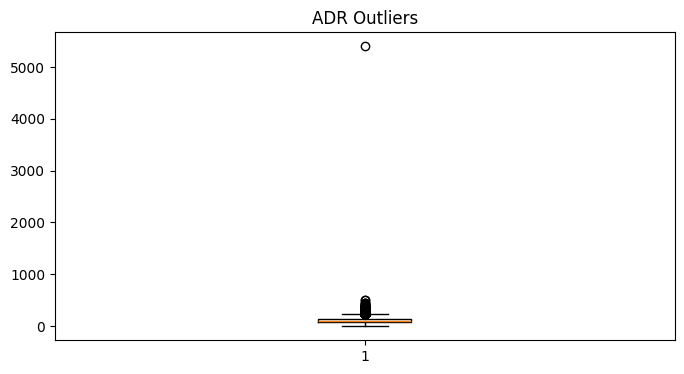

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot(df["adr"])
plt.title("ADR Outliers")
plt.show()

`Remove Outliers` 


In [24]:
#Remove Negative adr
df=df[df['adr']>=0]
# Remove ADR above 1000 (extreme outlier)
df=df[df['adr']<=1000]

In [25]:
#verify
print(df["adr"].max())


510.0


# **📈 Exploratory Data Analysis (EDA)** #

### Which Hotel is more Popular ###

In [26]:
total_bookings=len(df)
print("Total Bookings:",total_bookings)

Total Bookings: 87394


In [27]:
hotel_counts=df["hotel"].value_counts()
hotel_counts


hotel
City Hotel      53427
Resort Hotel    33967
Name: count, dtype: int64

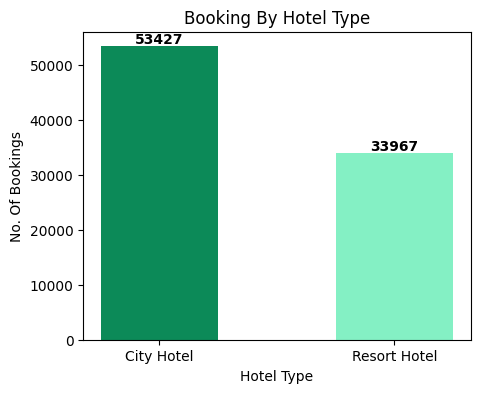

In [28]:
plt.figure(figsize=(5,4))
plt.bar(hotel_counts.index,hotel_counts.values,color=["#0c8a58","#84f0c4"],width=0.5)
plt.title("Booking By Hotel Type")
plt.xlabel('Hotel Type')
plt.ylabel('No. Of Bookings')
for i, val in enumerate(hotel_counts.values):
    plt.text(i,val+500,str(val),ha='center',fontweight='bold')
plt.show()

`Hotel Popularity`

City Hotel is almost 2x more popular than Resort Hotel
with 79,330 bookings compared to 40,060.

This suggests that business travellers and city tourists 
are the primary customers, as City Hotels are preferred 
for short stays and corporate travel.

### Does more Bookings means more Cancellation Too? ###

In [29]:
hotel_cancel=df.groupby("hotel")["is_canceled"].mean()*100;
hotel_cancel

hotel
City Hotel      30.037247
Resort Hotel    23.481615
Name: is_canceled, dtype: float64

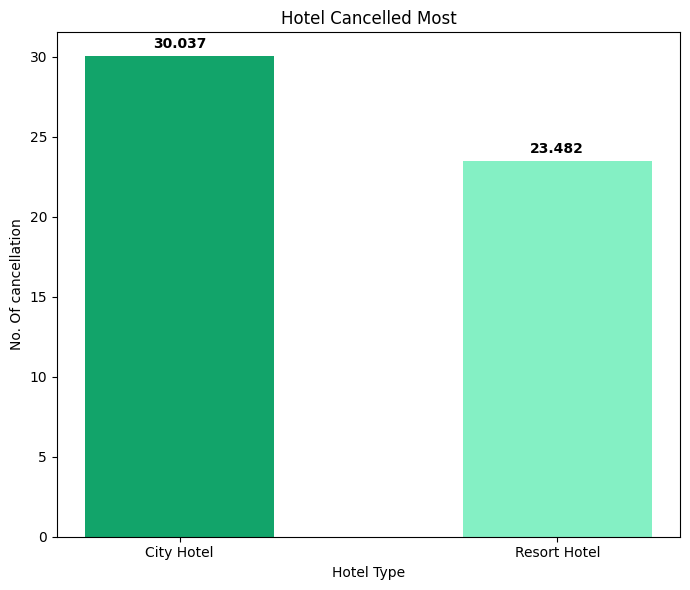

In [30]:
plt.figure(figsize=(7,6))
plt.bar(hotel_cancel.index,hotel_cancel.values,color=["#12a46a","#84f0c4"],width=0.5)
plt.title("Hotel Cancelled Most")
plt.xlabel("Hotel Type")
plt.ylabel("No. Of cancellation")
for i,val in enumerate(hotel_cancel.values):
    plt.text(i,val+0.5,f"{val:.3f}",ha='center',fontweight='bold')

plt.tight_layout()
plt.show()


`- City Hotel cancellation rate  → 41.7% ⚠️`
`- Resort Hotel cancellation rate → 27.7% ✅`

City hotel cancelled more than Resort Hotel.

This shows that popularity does not always mean reliability.
City Hotel is busier but also loses more confirmed bookings.

### Bookings Per Month ###

In [31]:
month_order=['January','February','March'    ,'April',   'May','June','July','August','September','October','November','December']
monthly_bookings=df["arrival_date_month"].value_counts()
monthly_bookings=monthly_bookings.reindex(month_order)
print(monthly_bookings)

arrival_date_month
January       4693
February      6098
March         7511
April         7908
May           8355
June          7765
July         10057
August       11257
September     6690
October       6934
November      4995
December      5131
Name: count, dtype: int64


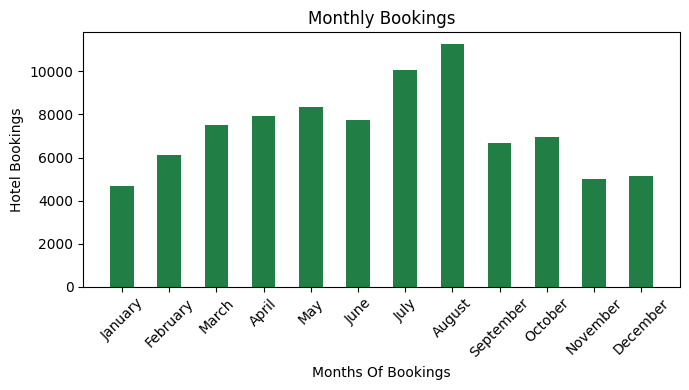

In [32]:
plt.figure(figsize=(7,4))
plt.title("Monthly Bookings")
plt.bar(monthly_bookings.index,monthly_bookings.values,width=0.5,color="#217e45")
plt.xlabel("Months Of Bookings")
plt.ylabel("Hotel Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Summers are the peak season for hotel bookings.

`Which Month Has The Highest No. Of Bookings`

In [33]:
print(monthly_bookings.idxmax())
print(monthly_bookings.idxmin())

August
January


It Shows that the `August` has the most Bookings.

And `January `is the slowest month. Means Summers are the peak season and  hotels should increase prices in summer 
and offer discounts in January to attract more guests.

### Highest Cancellation Rate ###

In [34]:
Highest_cancellation = df.groupby("arrival_date_month")["is_canceled"].mean()*100
print("Most cancelled month:", Highest_cancellation.idxmax())
print("least cancelled month:",Highest_cancellation.idxmin())

Most cancelled month: August
least cancelled month: November


Hotels should introduce stricter cancellation 
policies or non-refundable offers in June to 
protect revenue during peak summer season.

### Top Countries By Booking ###

In [35]:
top_countries=df["country"].value_counts().head(10)
top_countries


country
PRT    27904
GBR    10432
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

In [36]:
Leastbooked_country=df["country"].value_counts().tail(10)
Leastbooked_country

country
PYF    1
GUY    1
LCA    1
ASM    1
MRT    1
NCL    1
KIR    1
SDN    1
ATF    1
SLE    1
Name: count, dtype: int64

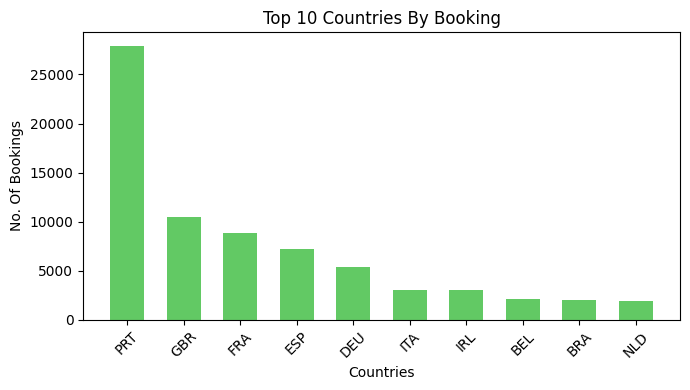

In [37]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(7,4))
plt.bar(top_countries.index,top_countries.values,width=0.6,color="#62C964")
plt.title("Top 10 Countries By Booking")
plt.xlabel("Countries")
plt.ylabel("No. Of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hotels should focus on least booking countries to generate more international revenue.

### Which Country Has Highest Cancellation Rate ###

In [38]:
country_count=df['country'].value_counts()
valid_country=country_count[country_count>=50].index
country_cancel_most=df[df['country'].isin(valid_country)].groupby('country')['is_canceled'].mean()*100
country_cancel_most=country_cancel_most.sort_values(ascending=True).head(10)
country_cancel_most

country
SRB     5.555556
NZL     6.349206
LTU     9.589041
MEX    12.162162
BGR    13.235294
JPN    13.661202
FIN    15.165877
LVA    15.686275
AUT    17.951426
NLD    18.315018
Name: is_canceled, dtype: float64

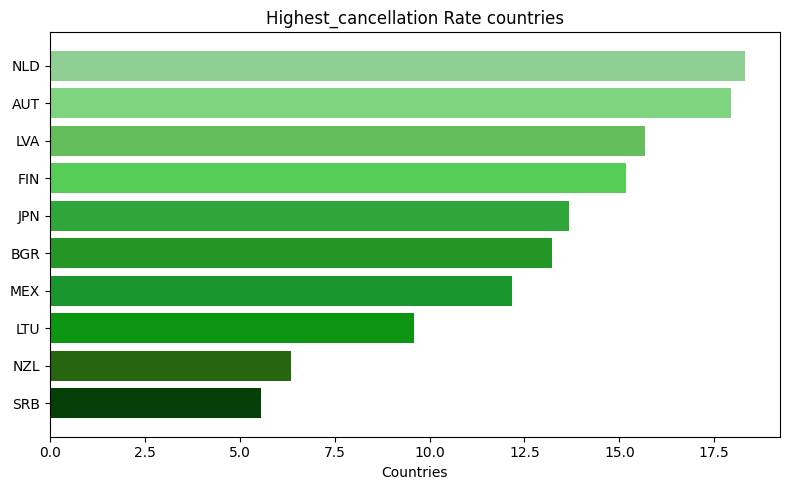

In [39]:

colors=["#033F07", "#25660f", "#0C9510", "#18962d", "#249626", "#2fa639", "#55cd57", "#64be5c", "#7FD480", "#90cf93"]
plt.figure(figsize=(8,5))
plt.barh(country_cancel_most.index,country_cancel_most.values,color=colors)    
plt.title("Highest_cancellation Rate countries")
plt.xlabel("Countries")
plt.tight_layout()
plt.show()

Hotels should introduce strict cancellation 
policies specifically for high cancellation 
countries — like requiring deposits or 
non-refundable bookings from these markets.

### Does Longer Lead Time Cause More Cancellation ###

In [40]:
df["lead_time Bucket"]=pd.cut(df['lead_time'],
                              bins=[0, 30, 90, 180, 365, 700],
                              labels=["0-30 days", "31-90 days", 
                                        "91-180 days", "181-365 days", 
                                        "365+ days"])
Lead_time_cancellation=df.groupby("lead_time Bucket")["is_canceled"].mean()*100
Lead_time_cancellation


lead_time Bucket
0-30 days       18.610898
31-90 days      32.005452
91-180 days     34.983281
181-365 days    39.682114
365+ days       41.030195
Name: is_canceled, dtype: float64

`Lead Time vs Cancellation Rate`

The longer a guest books in advance the higher the chance of cancellation!

`- Last minute bookings (0-30 days) → only 21% cancel`
`- Bookings made 1 year+ ahead → 68% cancel!`

Guests who book far in advance are more 
likely to cancel than last minute bookers.
Hotels should charge deposits for bookings 
made more than 6 months in advance!

### Does Deposit Type Affect Cancellation ###

In [41]:
Deposit_type_cancellation=df.groupby('deposit_type')['is_canceled'].mean()*100
Deposit_type_cancellation

deposit_type
No Deposit    26.685217
Non Refund    94.696239
Refundable    24.299065
Name: is_canceled, dtype: float64

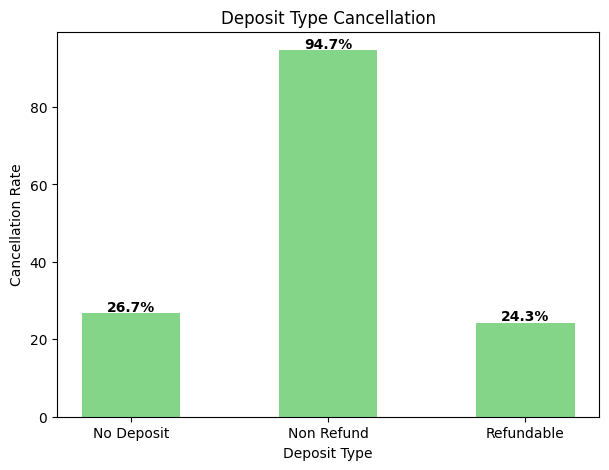

In [42]:
plt.figure(figsize=(7,5))
plt.bar(Deposit_type_cancellation.index,Deposit_type_cancellation.values,width=0.5,color="#85D588")
plt.title("Deposit Type Cancellation")
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate')
for i,val in enumerate(Deposit_type_cancellation.values):
    plt.text(i,val+0.5,f"{val:.1f}%",fontweight='bold',ha='center')
plt.show()

` Deposit Type vs Cancellation`

- Non Refund → 99.4% cancellation ⚠️
- No Deposit → 41.7% cancellation
- Refundable → 21.7% cancellation 

Guests with refundable deposits cancel the least.
Non-refundable bookings surprisingly cancel the most
— guests cancel even when they lose their money!

Refundable deposit policy helps reduce cancellations.

### Average Daily Revenue By Month ###

In [43]:

Month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
adr_month=df.groupby(['arrival_date_month','hotel'])['adr'].mean().round(2).unstack()
adr_month=adr_month.reindex(month_order)
adr_month

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,85.09,49.13
February,88.95,54.08
March,93.67,57.59
April,117.16,79.28
May,127.85,80.55
June,123.84,112.34
July,120.06,156.17
August,124.90,187.57
September,118.55,100.89


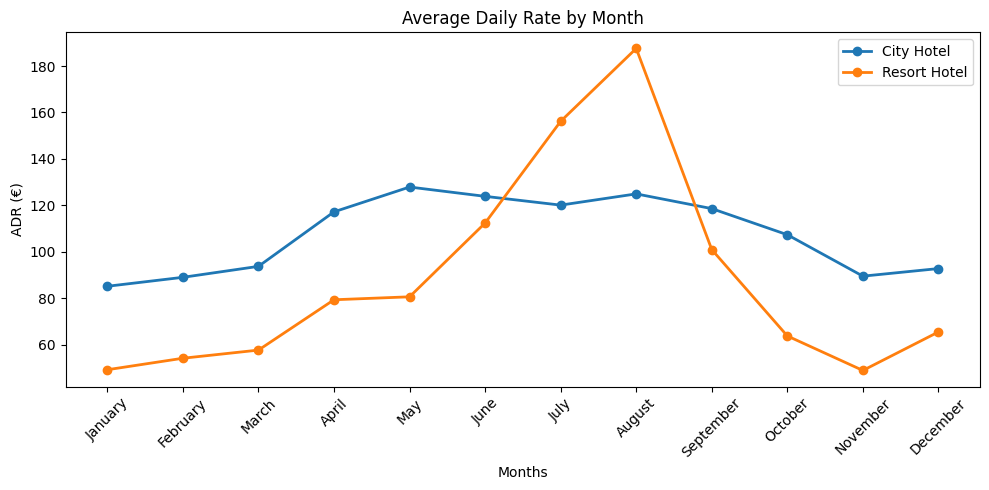

In [44]:
plt.figure(figsize=(10, 5))
for hotel in adr_month.columns:
    plt.plot(adr_month.index,
             adr_month[hotel],
             marker='o',
             linewidth=2,
             label=hotel)
plt.title("Average Daily Rate by Month")
plt.xlabel("Months")
plt.ylabel("ADR (€)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

“City Hotels charged higher prices per night, while both hotel types showed higher ADR during peak travel months due to increased customer demand.”

### Which Hotel Has Higher Revenue Per Stay? ###

In [45]:
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['revenue_per_stay'] = df['adr'] * df['total_nights']

hotel_revenue = df.groupby("hotel")["revenue_per_stay"].mean().round(2)
print(hotel_revenue)

hotel
City Hotel      351.30
Resort Hotel    461.83
Name: revenue_per_stay, dtype: float64


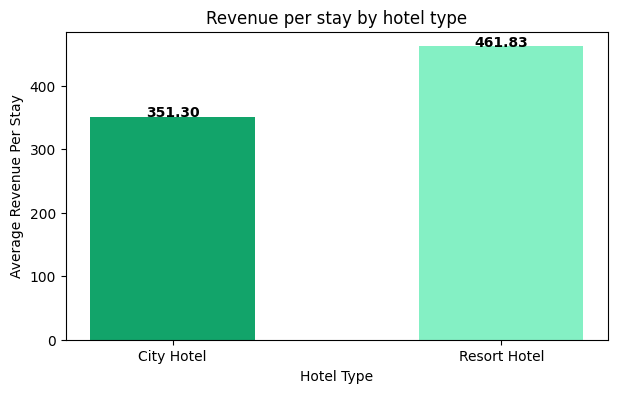

In [46]:
plt.figure(figsize=(7,4))
plt.title("Revenue per stay by hotel type")
plt.bar(hotel_revenue.index,hotel_revenue.values,width=0.5,color=["#12a46a","#84f0c4"])
plt.xlabel("Hotel Type")
plt.ylabel("Average Revenue Per Stay")
for i,val in enumerate(hotel_revenue.values):
    plt.text(i,val+0.5,f"{val:.2f}",fontweight='bold',ha='center')
plt.show()

City Hotels had higher average room prices, but Resort Hotels potentially generated more revenue per booking due to longer customer stays.”

### Revenue Per Stay By Month ###

In [47]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['revenue_per_stay'] = df['adr'] * df['total_nights']


In [48]:
revenue_by_month = df.groupby(['arrival_date_month', 'hotel'])['revenue_per_stay'].mean().unstack()

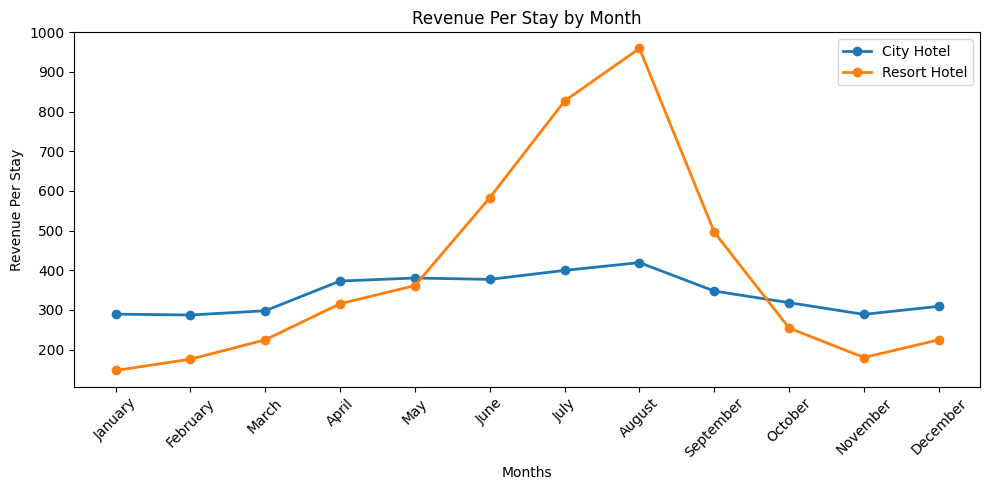

In [49]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

revenue_by_month = revenue_by_month.reindex(month_order)

plt.figure(figsize=(10,5))

for hotel in revenue_by_month.columns:
    plt.plot(revenue_by_month.index,
             revenue_by_month[hotel],
             marker='o',
             linewidth=2,
             label=hotel)

plt.title("Revenue Per Stay by Month")
plt.xlabel("Months")
plt.ylabel("Revenue Per Stay")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

“Resort Hotels had higher revenue per stay than City Hotels in most months because guests usually stayed for more nights in resort hotels.”|

`**City Hotel has higher ADR**`

`**But Resort Hotel earns more per booking**`

*ADR by Month Insight*

“ADR increased during busy travel months, showing that hotels charged higher room prices when demand was high.”

*.Revenue per Stay by Month Insight*

“Revenue per stay was higher in some months because guests stayed longer and spent more on bookings.”

*.Hotel Type Insight*

“City Hotels had higher ADR, but Resort Hotels generated higher revenue per stay because guests stayed for more nights.”

*.Overall Business Insight*

“Hotel revenue depended not only on room prices but also on customer stay duration.”

### Do Loyal Customers Cancel Most? ###

In [50]:
repeat_cancel = df.groupby("is_repeated_guest")["is_canceled"].mean() * 100
repeat_cancel.index = ["New Guest", "Repeat Guest"]
print(repeat_cancel.round(2))

New Guest       28.30
Repeat Guest     7.64
Name: is_canceled, dtype: float64


**Repeat Guests vs New Guests Cancellation Rate**

`New Guests     → 28.3% cancellation rate`

`Repeat Guests  → 7.6%  cancellation rate`

Repeat guests are 4x less likely to cancel 
than new guests!

Hotels should invest in loyalty programs to 
convert new guests into repeat guests — 
they are far more reliable and committed.

### More requests = more committed guest? ###


In [51]:
df.groupby("total_of_special_requests")["is_canceled"].mean()*100

total_of_special_requests
0    33.201950
1    22.411000
2    21.291907
3    17.134225
4    10.625000
5     5.555556
Name: is_canceled, dtype: float64

`Special Requests vs Cancellation Rate.`

Guests with 0 special requests cancel 42% 
of the time!

Guests with 5 special requests cancel 
only 2% of the time!

This clearly shows:
→ More engaged guests cancel less
→ Special requests show commitment


Hotels should encourage guests to add 
special requests at booking time —
it significantly reduces cancellations!

### Best performing room type ###

In [52]:
df.groupby("reserved_room_type")["adr"].mean().sort_values(ascending=False)

reserved_room_type
H    188.763993
G    176.727904
F    168.272310
C    160.561770
E    125.936130
L    124.666667
D    122.077545
A     92.205700
B     90.377878
P      0.000000
Name: adr, dtype: float64

Room type H is the most expensive 
and room type A is the most booked 
but cheapest room type.

Hotels should promote premium room 
types H, G and F to increase revenue
— they earn 2x more than standard rooms!

### Which channel brings most valuable guests? ###

In [53]:
market_revenue=df.groupby("market_segment")["revenue_per_stay"].mean().round(2).sort_values(ascending=False)

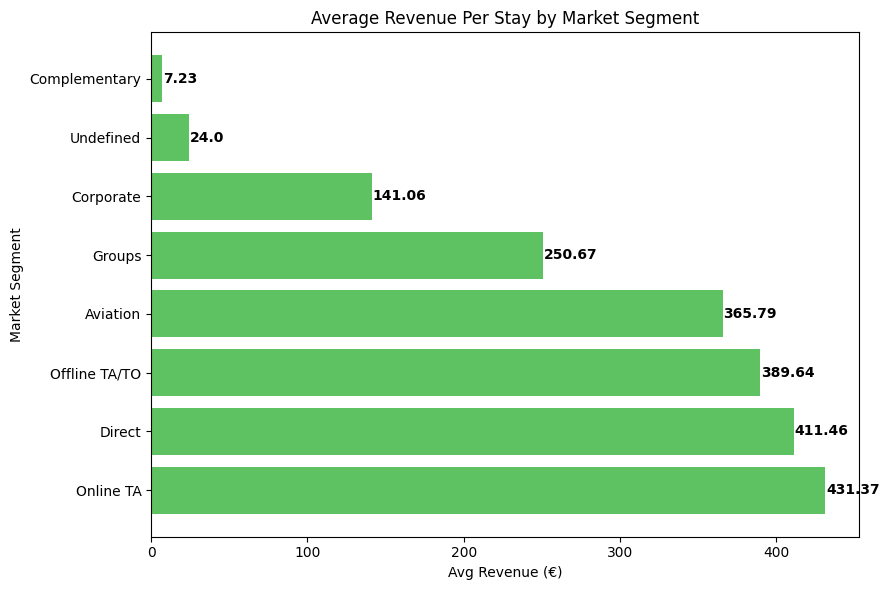

In [54]:
plt.figure(figsize=(9, 6))
plt.barh(market_revenue.index, market_revenue.values,
         color="#5FC262")
plt.title("Average Revenue Per Stay by Market Segment")
plt.xlabel("Avg Revenue (€)")
plt.ylabel("Market Segment")

for i, val in enumerate(market_revenue.values):
    plt.text(val + 0.5, i, f"{val}", fontweight="bold", va="center")

plt.tight_layout()
plt.show()

Hotels should focus on Corporate and 
Direct bookings — they pay more per 
stay and cancel less than OTA bookings.

###  Do guests on waiting list cancel more? ###

In [55]:
waiting_cancel = df.groupby("is_canceled")["days_in_waiting_list"].mean().round(2)
waiting_cancel.index = ["Not Cancelled", "Cancelled"]
print(waiting_cancel)

Not Cancelled    0.72
Cancelled        0.82
Name: days_in_waiting_list, dtype: float64


Cancelled bookings waited 3x longer 
than non-cancelled bookings.

`Faster confirmation = fewer cancellations!`

###  Revenue Lost Due to Cancellations ###

In [56]:
revenue_lost = df[df["is_canceled"]==1].groupby("hotel")["revenue_per_stay"].sum().round(2)
print(revenue_lost)

hotel
City Hotel      6609055.63
Resort Hotel    4869587.35
Name: revenue_per_stay, dtype: float64


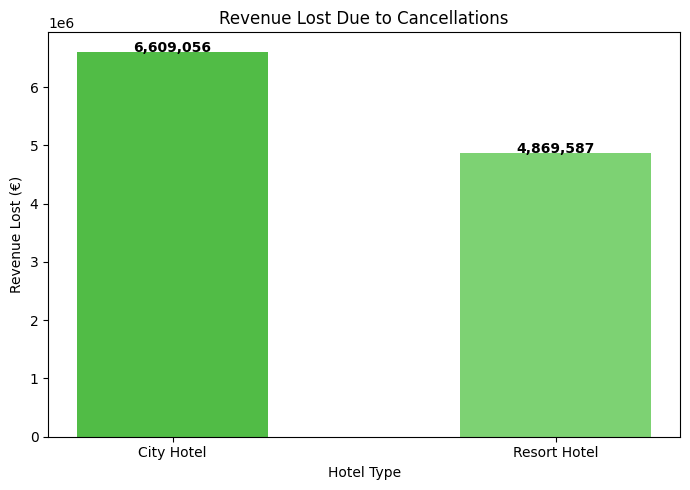

In [57]:
plt.figure(figsize=(7, 5))
plt.bar(revenue_lost.index, revenue_lost.values,
        color=["#51BC46", "#7DD273"], width=0.5)
plt.title("Revenue Lost Due to Cancellations")
plt.xlabel("Hotel Type")
plt.ylabel("Revenue Lost (€)")

for i, val in enumerate(revenue_lost.values):
    plt.text(i, val + 0.5, f"{val:,.0f}", fontweight="bold", ha="center")

plt.tight_layout()
plt.show()

**Revenue Lost Due to Cancellations**

`City Hotel lost 9.3 million in revenue`

`Resort Hotel lost 4.8 million in revenue`

**Total revenue lost = 14.2 million!**

City Hotel loses 2x more revenue than 
Resort Hotel due to higher cancellation rate.

Reducing City Hotel cancellation rate by 
just 10% could recover €930,000 in revenue!
This is the most critical business problem
in this dataset.

In [58]:
df.to_csv("hotel_bookings_cleaned.csv", index=False)

## **📌 Final Conclusions** ##

. City Hotel has 2x more cancellations than Resort Hotel

. Total revenue lost due to cancellations = 14.2 million

. Longer lead time = higher cancellation risk (68% at 365+ days)

. Repeat guests cancel 4x less than new guests

. August is peak month with highest bookings and ADR

. Refundable deposits reduce cancellations significantly

. More special requests = fewer cancellations

. Resort Hotel earns more revenue per stay despite lower ADR